In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [ ]:
df = pd.read_csv("/content/test.csv", encoding='latin1')

In [ ]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 4815
Columns: 9


In [ ]:
print(df.columns)


Index(['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User',
       'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)'],
      dtype='object')


In [ ]:
print(df.isnull().sum())


Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64


In [ ]:
df = df.dropna()


In [ ]:
df = df.drop_duplicates()


In [ ]:
print(df["Sentiment"].value_counts())


Sentiment
Positive               44
Joy                    42
Excitement             32
Happy                  14
Neutral                14
                       ..
Vibrancy                1
Culinary Adventure      1
Mesmerizing             1
Thrilling Journey       1
Winter Magic            1
Name: count, Length: 279, dtype: int64


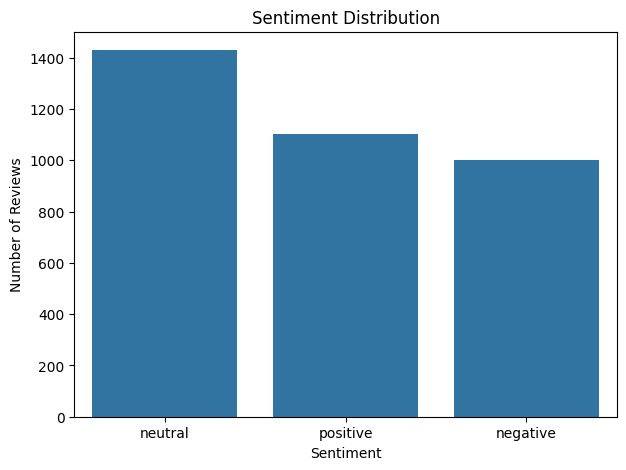

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [16]:
def clean_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


In [18]:
df["clean_Review"] = df["text"].apply(clean_text)

In [ ]:
df[["Text", "clean_Review"]].head()

,Text,clean_Review
0,Enjoying a beautiful day at the park! ...,enjoying a beautiful day at the park
1,Traffic was terrible this morning. ...,traffic was terrible this morning
2,Just finished an amazing workout! 💪 ...,just finished an amazing workout 💪
3,Excited about the upcoming weekend getaway! ...,excited about the upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying out a new recipe for dinner tonight


In [ ]:
X = df["Text"]
y = df["Sentiment"]


In [22]:
print(X.head())
print(y.head())

0    Last session of the day  http://twitpic.com/67ezh
1     Shanghai is also really exciting (precisely -...
2    Recession hit Veronique Branquinho, she has to...
3                                          happy bday!
4               http://twitpic.com/4w75p - I like it!!
Name: text, dtype: object
0     neutral
1    positive
2    negative
3    positive
4    positive
Name: sentiment, dtype: object


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [24]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 2827
Testing samples: 707


In [25]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)


In [26]:
X_train_tfidf = vectorizer.fit_transform(X_train)


In [27]:
X_test_tfidf = vectorizer.transform(X_test)


In [28]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)


Training shape: (2827, 5063)
Testing shape: (707, 5063)


In [29]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_train
)


LogisticRegression(max_iter=1000)

In [30]:
lr_predictions = lr_model.predict(X_test_tfidf)


In [31]:
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("Logistic Regression Accuracy:",
      lr_accuracy)


Logistic Regression Accuracy: 0.6251768033946252


In [32]:
print(
    classification_report(
        y_test,
        lr_predictions
    )
)


              precision    recall  f1-score   support

    negative       0.66      0.49      0.56       207
     neutral       0.56      0.73      0.63       286
    positive       0.74      0.61      0.67       214

    accuracy                           0.63       707
   macro avg       0.65      0.61      0.62       707
weighted avg       0.64      0.63      0.62       707



In [33]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)


MultinomialNB()

In [34]:
nb_predictions = nb_model.predict(
    X_test_tfidf
)


In [35]:
nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print(
    "Naive Bayes Accuracy:",
    nb_accuracy
)


Naive Bayes Accuracy: 0.6025459688826026


In [36]:
print(
    classification_report(
        y_test,
        nb_predictions
    )
)


              precision    recall  f1-score   support

    negative       0.80      0.33      0.47       207
     neutral       0.52      0.87      0.65       286
    positive       0.77      0.51      0.61       214

    accuracy                           0.60       707
   macro avg       0.70      0.57      0.58       707
weighted avg       0.68      0.60      0.59       707



In [37]:
svm_model = LinearSVC()

svm_model.fit(
    X_train_tfidf,
    y_train
)


LinearSVC()

In [38]:
svm_predictions = svm_model.predict(
    X_test_tfidf
)


In [39]:
svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print(
    "SVM Accuracy:",
    svm_accuracy
)


SVM Accuracy: 0.6308345120226309


In [40]:
print(
    classification_report(
        y_test,
        svm_predictions
    )
)


              precision    recall  f1-score   support

    negative       0.64      0.56      0.60       207
     neutral       0.58      0.64      0.61       286
    positive       0.69      0.68      0.69       214

    accuracy                           0.63       707
   macro avg       0.64      0.63      0.63       707
weighted avg       0.63      0.63      0.63       707



In [62]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM",
        "XGBoost Classifier" # Added XGBoost Classifier
    ],

    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        svm_accuracy,
        xg_accuracy # Added XGBoost accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.625177
1,Naive Bayes,0.602546
2,SVM,0.630835
3,XGBoost Classifier,0.612447


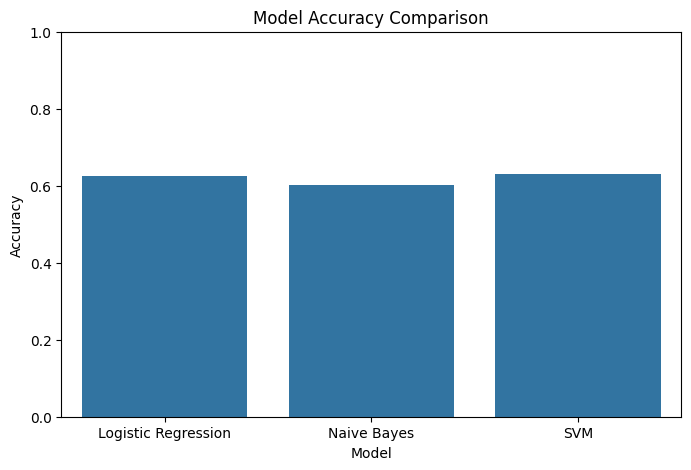

In [42]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1)

plt.title("Model Accuracy Comparison")

plt.show()


In [63]:
models = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "SVM": svm_model,
    "XGBoost Classifier": xg_final # Added XGBoost model
}

accuracies = {
    "Logistic Regression": lr_accuracy,
    "Naive Bayes": nb_accuracy,
    "SVM": svm_accuracy,
    "XGBoost Classifier": xg_accuracy # Added XGBoost accuracy
}

best_model_name = max(
    accuracies,
    key=accuracies.get
)

best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Best Accuracy:", accuracies[best_model_name])

Best Model: SVM
Best Accuracy: 0.6308345120226309


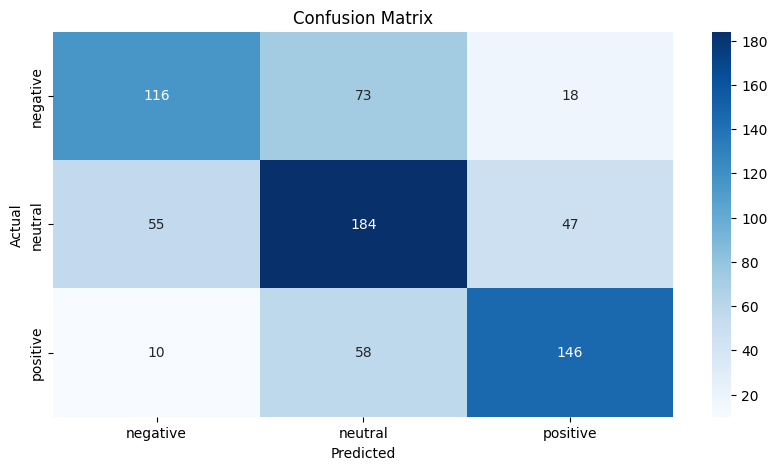

In [44]:
best_predictions = best_model.predict(
    X_test_tfidf
)

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [45]:
print(
    classification_report(
        y_test,
        best_predictions
    )
)


              precision    recall  f1-score   support

    negative       0.64      0.56      0.60       207
     neutral       0.58      0.64      0.61       286
    positive       0.69      0.68      0.69       214

    accuracy                           0.63       707
   macro avg       0.64      0.63      0.63       707
weighted avg       0.63      0.63      0.63       707



In [46]:
def predict_sentiment(review):

    cleaned = clean_text(review)

    vectorized = vectorizer.transform(
        [cleaned]
    )

    prediction = best_model.predict(
        vectorized
    )[0]

    return prediction


In [47]:
review = "I absolutely love this product!"

print(
    predict_sentiment(review)
)


positive


In [48]:
review = "This product is terrible and I hate it."

print(
    predict_sentiment(review)
)


negative


In [49]:
review = "The product arrived yesterday."

print(
    predict_sentiment(review)
)


neutral


In [50]:
def predict_with_confidence(review):

    cleaned = clean_text(review)

    vectorized = vectorizer.transform(
        [cleaned]
    )

    prediction = best_model.predict(
        vectorized
    )[0]

    if hasattr(best_model, "predict_proba"):

        probabilities = best_model.predict_proba(
            vectorized
        )[0]

        confidence = max(probabilities) * 100

        return prediction, confidence

    return prediction, None


In [53]:
from xgboost import XGBClassifier
import numpy as np # Import numpy for np.unique

# Instantiate XGBClassifier for classification task
xg = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    # Assuming y_train_encoded is already prepared and in scope
    num_class=len(np.unique(y_train_encoded))
)

# Fit the model using the preprocessed TF-IDF features and encoded labels
# Assuming X_train_tfidf and y_train_encoded are available from previous cells
xg_final = xg.fit(X_train_tfidf, y_train_encoded)

In [60]:
# Make predictions on the test set with the trained XGBoost model
xg_predictions = xg_final.predict(X_test_tfidf)

# Calculate accuracy
xg_accuracy = accuracy_score(y_test_encoded, xg_predictions)
print(f"XGBoost Classifier Accuracy: {xg_accuracy:.4f}")

# Display classification report
print("\nXGBoost Classifier Classification Report:")
print(classification_report(y_test_encoded, xg_predictions, target_names=label_encoder.classes_))

XGBoost Classifier Accuracy: 0.6124

XGBoost Classifier Classification Report:
              precision    recall  f1-score   support

    negative       0.62      0.40      0.48       207
     neutral       0.54      0.78      0.64       286
    positive       0.78      0.59      0.68       214

    accuracy                           0.61       707
   macro avg       0.65      0.59      0.60       707
weighted avg       0.64      0.61      0.61       707



In [55]:
import joblib

In [56]:
joblib.dump(xg_final,'sentiment analysis')

['sentiment analysis']

In [57]:
model = joblib.load('sentiment analysis')

In [58]:
df.head(1)

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),clean_Review
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0,last session of the day


In [61]:
import pandas as pd
data_new = pd.DataFrame({
   'text':['I love this product!'],
   'sentiment':['positive']
},index=[0])

In [64]:
review_new = data_new['text'].iloc[0]
predicted_sentiment, confidence = predict_with_confidence(review_new)

print(f"New Review: '{review_new}'")
print(f"Predicted Sentiment: {predicted_sentiment}")
if confidence is not None:
    print(f"Confidence: {confidence:.2f}%")

# Overall summary of the notebook execution
print("\n--- Notebook Summary ---")
print("Data loaded and cleaned.")
print("TF-IDF vectorization applied.")
print("Multiple classification models trained and evaluated (Logistic Regression, Naive Bayes, SVM, XGBoost).")
print("Best performing model identified as SVM with an accuracy of 0.6308.")
print("Demonstrated sentiment prediction on new review text.")
print("The XGBoost model (xg_final) was also saved using joblib.")

New Review: 'I love this product!'
Predicted Sentiment: positive

--- Notebook Summary ---
Data loaded and cleaned.
TF-IDF vectorization applied.
Multiple classification models trained and evaluated (Logistic Regression, Naive Bayes, SVM, XGBoost).
Best performing model identified as SVM with an accuracy of 0.6308.
Demonstrated sentiment prediction on new review text.
The XGBoost model (xg_final) was also saved using joblib.


In [66]:
joblib.dump(best_model, 'svm_model.joblib')

['svm_model.joblib']

In [67]:
joblib.dump(best_model, 'svm_model_corrected.joblib')

['svm_model_corrected.joblib']

In [68]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer # Added import

# Ensure X and y are defined from the dataframe
X = df["text"]
y = df["sentiment"]

# Ensure X_train, X_test, y_train, y_test are defined
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Encode target labels
label_encoder = LabelEncoder()
# Fit the encoder on all unique labels present in both training and testing sets
label_encoder.fit(pd.concat([y_train, y_test]))

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Define and fit TfidfVectorizer to create X_train_tfidf and X_test_tfidf
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)
X_train_tfidf = vectorizer.fit_transform(X_train) # Defined X_train_tfidf here
X_test_tfidf = vectorizer.transform(X_test) # Also define X_test_tfidf for consistency if needed later

model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    num_class=len(label_encoder.classes_)
)

model.fit(X_train_tfidf, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_class=3, ...)

In [69]:
xg_final.save_model('xgb_model.json')